In [10]:
# --- Path setup ---
import sys
import os
import warnings
from pathlib import Path

_root = Path.cwd()
while _root != _root.parent and not (_root / "max_k_cut").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

# --- Scientific / data ---
import networkx as nx
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
plt.rcParams.update(
    {
        "figure.dpi": 200,
        "savefig.dpi": 600,
        "font.size": 11,
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "legend.fontsize": 10,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "text.usetex": False,
        "mathtext.fontset": "cm",
    }
)

# --- Qiskit ecosystem ---
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector
from qiskit_optimization.translators import from_docplex_mp

# --- Project ---
from max_k_cut import (
    docplex_QUBO, docplex_RQUBO, docplex_QUBO_no_constraints,
    tight_qubo_penalty, naive_qubo_penalty,
    tight_rqubo_penalty, naive_rqubo_penalty,
    create_dicke_initial_state, create_ring_xy_mixer,
    plot_graph,
)

warnings.filterwarnings("ignore", category=DeprecationWarning)

DATA_DIR = "Data"
os.makedirs(DATA_DIR, exist_ok=True)
print("Data directory:", os.path.abspath(DATA_DIR))

Data directory: /Users/hark469/Projects/max-k-cut/Max_K_Cut/notebooks/experiments/Data


In [18]:
# ── Configuration ──
K = 3                          # number of partitions
GRID_RES = 1000                 # resolution per axis (100 × 100 grid)
GAMMA_RANGE = (0, 2 * np.pi)  # phase-separation parameter range
BETA_RANGE  = (0, np.pi)      # mixer parameter range

CONTOUR_LEVELS = 200            # number of contour levels in filled plots
CMAP = "RdYlBu_r"             # diverging colormap: red (high) to blue (low)

Graph: 4 nodes, 6 edges
QUBO qubits: 12,  RQUBO qubits: 8


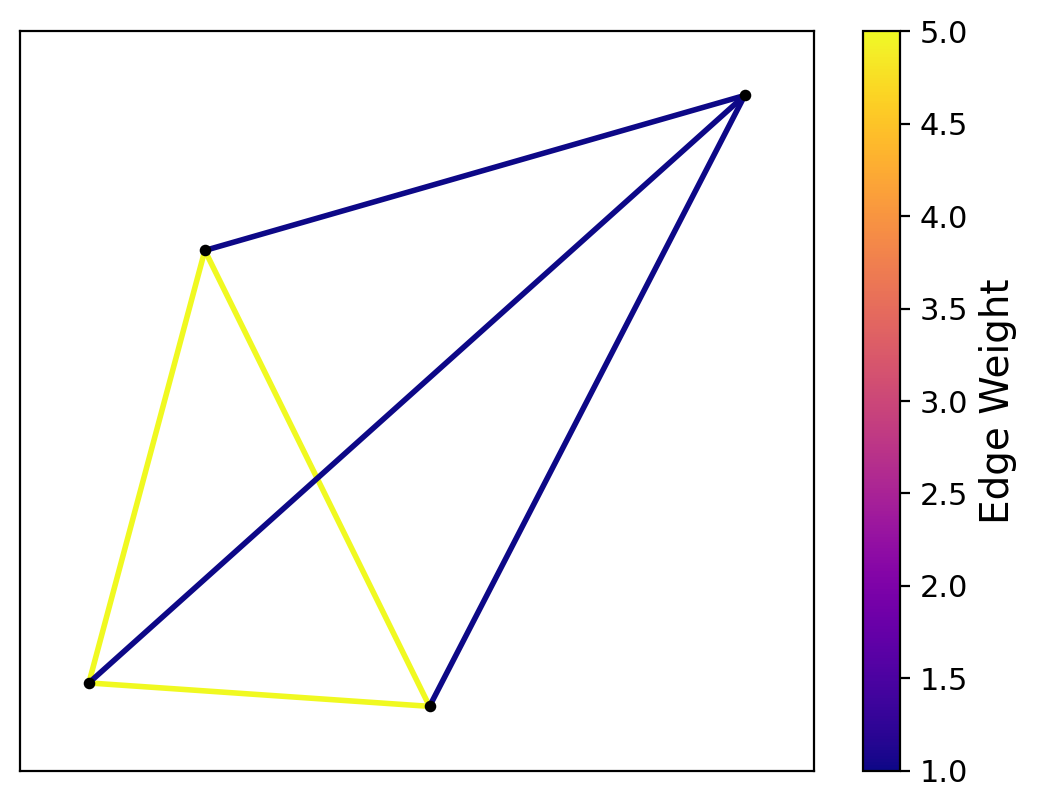

In [12]:
# ── Graph construction ──
# 4-node weighted graph: outer triangle (weight M) + spokes to u~ (weight alpha)
M, alpha = 5, 1
G = nx.Graph()
G.add_edge(0, 1, weight=M)       # u1-u2
G.add_edge(1, 2, weight=M)       # u2-u3
G.add_edge(2, 0, weight=M)       # u3-u1
G.add_edge(0, 3, weight=alpha)   # u1-u~
G.add_edge(1, 3, weight=alpha)   # u2-u~
G.add_edge(2, 3, weight=alpha)   # u3-u~
num_nodes = G.number_of_nodes()

print(f"Graph: {num_nodes} nodes, {G.number_of_edges()} edges")
print(f"QUBO qubits: {num_nodes * K},  RQUBO qubits: {num_nodes * (K - 1)}")
plot_graph(G)

In [13]:
# ── Build Docplex models and convert to Ising Hamiltonians ──

penalty_tight_qubo  = tight_qubo_penalty(G, K)
penalty_naive_qubo  = naive_qubo_penalty(G, K)
penalty_tight_rqubo = tight_rqubo_penalty(G, K)
penalty_naive_rqubo = naive_rqubo_penalty(G, K)

dp_models = {
    "QUBO tight":  docplex_QUBO(G, K, penalty_tight_qubo,  "QUBO_tight"),
    "QUBO naive":  docplex_QUBO(G, K, penalty_naive_qubo,  "QUBO_naive"),
    "QUBO (XY)":   docplex_QUBO_no_constraints(G, K, "QUBO_xy"),
    "RQUBO tight": docplex_RQUBO(G, K, penalty_tight_rqubo, "RQUBO_tight"),
    "RQUBO naive": docplex_RQUBO(G, K, penalty_naive_rqubo, "RQUBO_naive"),
}

ising = {}
for label, dp in dp_models.items():
    qp = from_docplex_mp(dp)
    op, offset = qp.to_ising()
    classical_opt = dp.solve().objective_value
    ising[label] = {"operator": op, "offset": offset, "classical_opt": classical_opt}
    print(f"{label:16s}  qubits={op.num_qubits:2d}  "
          f"offset={offset:+.4f}  classical_opt={classical_opt:.4f}")

print(f"\nPenalty vectors (QUBO):  tight={penalty_tight_qubo},  naive={penalty_naive_qubo}")
print(f"Penalty vectors (RQUBO): tight={penalty_tight_rqubo},  naive={penalty_naive_rqubo}")

QUBO tight        qubits=12  offset=+7.5000  classical_opt=17.0000
QUBO naive        qubits=12  offset=+67.5000  classical_opt=17.0000
QUBO (XY)         qubits=12  offset=-4.5000  classical_opt=18.0000
RQUBO tight       qubits= 8  offset=+0.0000  classical_opt=17.0000
RQUBO naive       qubits= 8  offset=+9.0000  classical_opt=17.0000

Penalty vectors (QUBO):  tight=[3.66666667 3.66666667 3.66666667 1.        ],  naive=[18. 18. 18. 18.]
Penalty vectors (RQUBO): tight=[11. 11. 11.  3.],  naive=[18. 18. 18. 18.]


In [14]:
def _rxx_matrix(theta):
    """4x4 unitary for Rxx(theta) = exp(-i theta X*X / 2)."""
    c = np.cos(theta / 2)
    s = -1j * np.sin(theta / 2)
    return np.array([[c, 0, 0, s],
                     [0, c, s, 0],
                     [0, s, c, 0],
                     [s, 0, 0, c]])

def _ryy_matrix(theta):
    """4x4 unitary for Ryy(theta) = exp(-i theta Y*Y / 2)."""
    c = np.cos(theta / 2)
    s = np.sin(theta / 2)
    return np.array([[c,    0,     0,     1j*s],
                     [0,    c,    -1j*s,  0   ],
                     [0,   -1j*s,  c,     0   ],
                     [1j*s, 0,     0,     c   ]])

def _apply_2q_gate(Psi, gate, q1, q2, n):
    """Apply a 4x4 gate to qubits q1,q2 of a batched state (2^n x batch)."""
    dim = 2 ** n
    m1, m2 = 1 << q1, 1 << q2
    all_idx = np.arange(dim)
    rest = all_idx[(all_idx & m1 == 0) & (all_idx & m2 == 0)]
    idx = np.array([rest, rest | m2, rest | m1, rest | m1 | m2])
    v = Psi[idx]                                      # (4, dim/4, batch)
    r = np.einsum("il,ljk->ijk", gate, v)
    Psi[idx] = r

def _parse_mixer_gates(mixer):
    """Extract the (gate_name, q1, q2) sequence from a parametrised mixer circuit."""
    seq = []
    for ci in mixer.data:
        if ci.operation.name == "barrier":
            continue
        q_idx = [mixer.find_bit(q).index for q in ci.qubits]
        seq.append((ci.operation.name, q_idx[0], q_idx[1]))
    return seq

def compute_landscape(cost_op, offset, gamma_vals, beta_vals,
                      mixer=None, initial_state=None):
    """Exact p=1 QAOA expected cost landscape via direct linear-algebra.

    The Ising cost operator is diagonal in the Z-basis, so the cost evolution
    is a cheap element-wise phase.  The mixer is applied gate-by-gate,
    vectorised over all gamma values simultaneously.

    Returns the *original* (maximisation) objective: -(⟨H_ising⟩ + offset).
    """
    n = cost_op.num_qubits
    dim = 2 ** n

    cost_diag = np.asarray(cost_op.to_matrix().diagonal()).real

    if initial_state is not None:
        psi0 = Statevector(initial_state).data
    else:
        psi0 = np.full(dim, 1.0 / np.sqrt(dim), dtype=complex)

    Psi1 = np.exp(-1j * np.outer(cost_diag, gamma_vals)) * psi0[:, np.newaxis]
    landscape = np.empty((len(beta_vals), len(gamma_vals)))

    if mixer is None:
        for i, bv in enumerate(beta_vals):
            Psi2 = Psi1.copy()
            c, s = np.cos(bv), -1j * np.sin(bv)
            for q in range(n):
                half = 1 << q
                step = half << 1
                for blk in range(0, dim, step):
                    lo = slice(blk, blk + half)
                    hi = slice(blk + half, blk + step)
                    a, b = Psi2[lo].copy(), Psi2[hi].copy()
                    Psi2[lo] = c * a + s * b
                    Psi2[hi] = s * a + c * b
            landscape[i, :] = -(cost_diag @ np.abs(Psi2) ** 2 + offset)
    else:
        gate_seq = _parse_mixer_gates(mixer)
        gate_builders = {"rxx": _rxx_matrix, "ryy": _ryy_matrix}
        for i, bv in enumerate(beta_vals):
            Psi2 = Psi1.copy()
            for gname, q1, q2 in gate_seq:
                theta = 2 * bv
                _apply_2q_gate(Psi2, gate_builders[gname](theta), q1, q2, n)
            landscape[i, :] = -(cost_diag @ np.abs(Psi2) ** 2 + offset)

    return landscape

In [15]:
# ── Compute all landscapes ──
import time

gamma_vals = np.linspace(*GAMMA_RANGE, GRID_RES)
beta_vals  = np.linspace(*BETA_RANGE,  GRID_RES)

# -- Penalty models (default |+⟩ initial state, X-mixer) --
landscapes = {}
for label in ["QUBO tight", "QUBO naive", "RQUBO tight", "RQUBO naive"]:
    t0 = time.time()
    landscapes[label] = compute_landscape(
        ising[label]["operator"], ising[label]["offset"],
        gamma_vals, beta_vals,
    )
    print(f"{label:16s}  {time.time() - t0:.1f}s")

# -- XY-mixer model (Dicke initial state + ring XY mixer) --
beta_param = Parameter("β")
xy_mixer   = create_ring_xy_mixer(num_nodes, K, beta_param)
dicke_init = create_dicke_initial_state(num_nodes, K)

t0 = time.time()
landscapes["QUBO (XY)"] = compute_landscape(
    ising["QUBO (XY)"]["operator"], ising["QUBO (XY)"]["offset"],
    gamma_vals, beta_vals,
    mixer=xy_mixer, initial_state=dicke_init,
)
print(f"{'QUBO (XY)':16s}  {time.time() - t0:.1f}s")

# -- Locate optima on each landscape --
optima = {}
for label, land in landscapes.items():
    idx = np.unravel_index(np.argmax(land), land.shape)
    optima[label] = (gamma_vals[idx[1]], beta_vals[idx[0]], land[idx])
    print(f"{label:16s}  optimum at (γ={optima[label][0]:.3f}, β={optima[label][1]:.3f})  "
          f"value={optima[label][2]:.4f}  (classical={ising[label]['classical_opt']:.4f})")

QUBO tight        395.8s
QUBO naive        395.1s
RQUBO tight       28.9s
RQUBO naive       30.1s
QUBO (XY)         1732.1s
QUBO tight        optimum at (γ=0.094, β=2.673)  value=10.1068  (classical=17.0000)
QUBO naive        optimum at (γ=6.258, β=0.390)  value=-11.0099  (classical=17.0000)
RQUBO tight       optimum at (γ=0.063, β=2.764)  value=11.8389  (classical=17.0000)
RQUBO naive       optimum at (γ=0.050, β=2.726)  value=11.2664  (classical=17.0000)
QUBO (XY)         optimum at (γ=0.170, β=3.035)  value=14.8585  (classical=18.0000)


Saved: Data/cost_landscape_QUBO.pdf


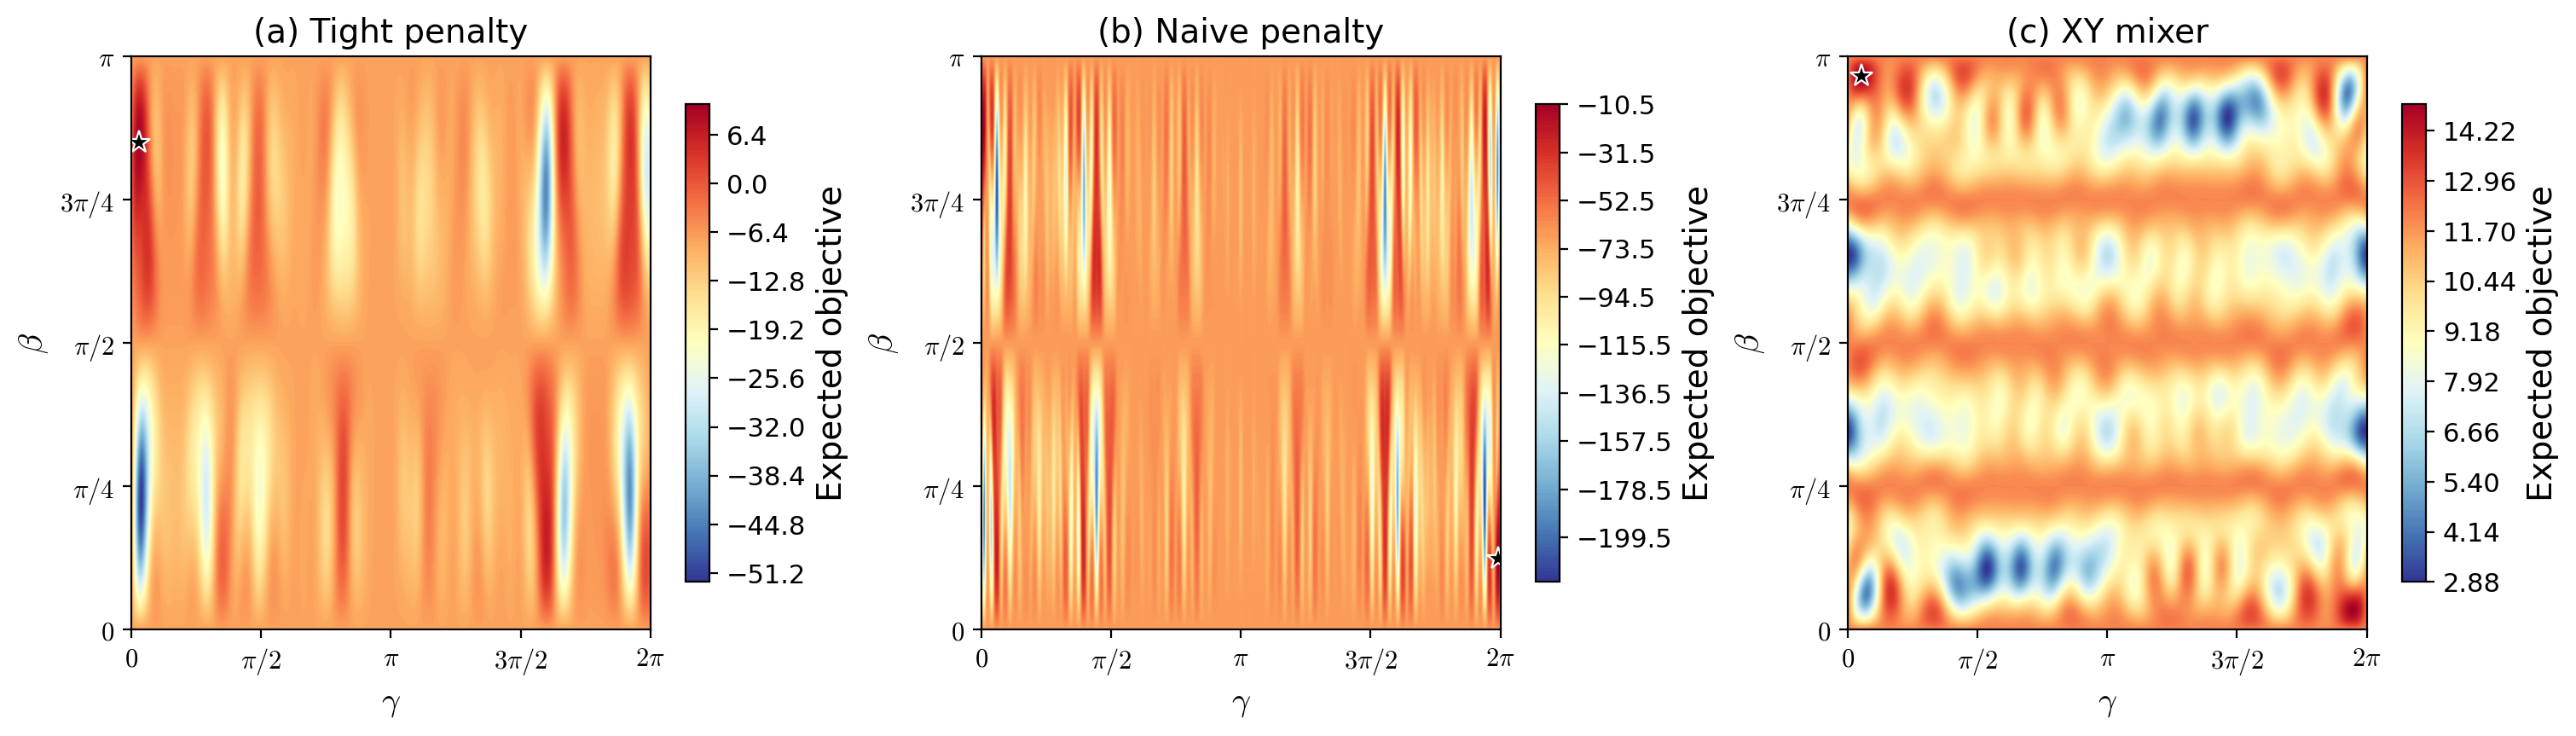

In [19]:
# ── Figure 1: QUBO landscapes (tight penalty | naive penalty | XY mixer) ──
qubo_labels = ["QUBO tight", "QUBO naive", "QUBO (XY)"]
panel_titles = ["(a) Tight penalty", "(b) Naive penalty", "(c) XY mixer"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)

GAMMA, BETA = np.meshgrid(gamma_vals, beta_vals)

for ax, label, title in zip(axes, qubo_labels, panel_titles):
    land = landscapes[label]
    cf = ax.contourf(GAMMA, BETA, land, levels=CONTOUR_LEVELS, cmap=CMAP)
    cbar = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Expected objective")

    gopt, bopt, _ = optima[label]
    ax.plot(gopt, bopt, marker="*", color="black", markersize=10, markeredgecolor="white",
            markeredgewidth=0.8)

    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel(r"$\beta$")
    ax.set_title(title)
    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax.set_yticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
    ax.set_yticklabels([r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])

qubo_pdf = os.path.join(DATA_DIR, "cost_landscape_QUBO.pdf")
fig.savefig(qubo_pdf, bbox_inches="tight")
print("Saved:", qubo_pdf)
plt.show()

Saved: Data/cost_landscape_RQUBO.pdf


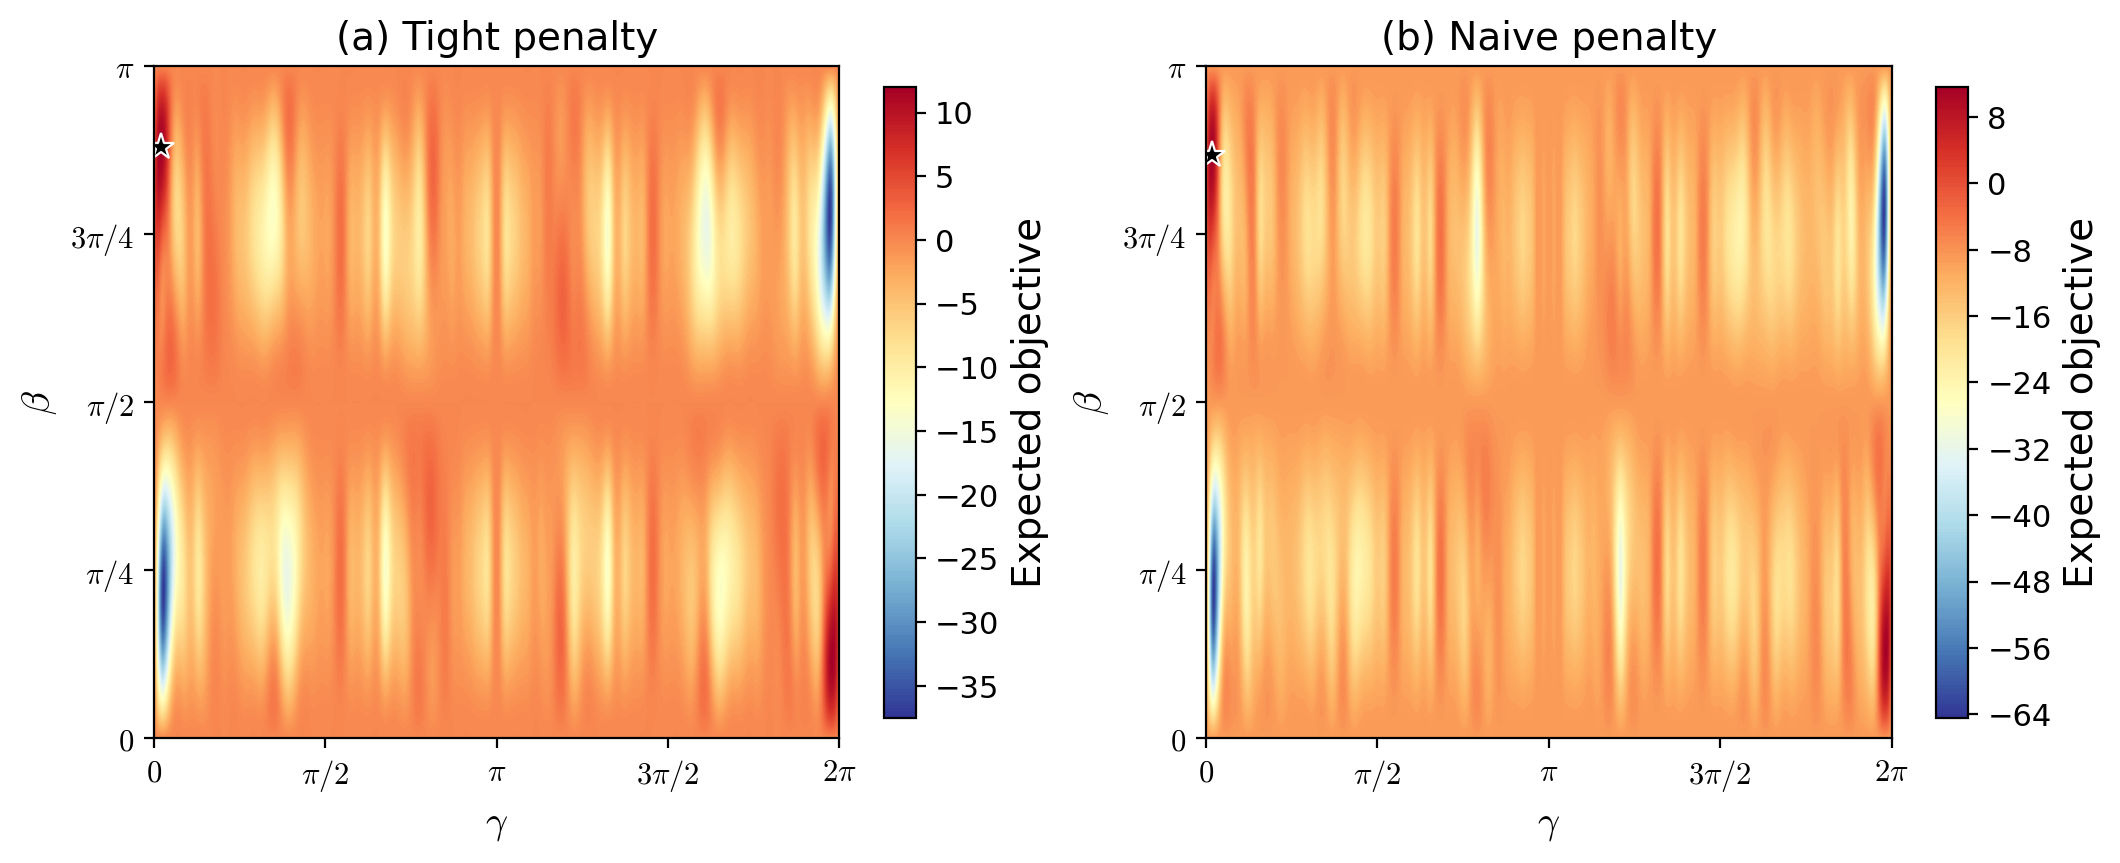

In [20]:
# ── Figure 2: RQUBO landscapes (tight penalty | naive penalty) ──
rqubo_labels = ["RQUBO tight", "RQUBO naive"]
rqubo_titles = ["(a) Tight penalty", "(b) Naive penalty"]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)

for ax, label, title in zip(axes, rqubo_labels, rqubo_titles):
    land = landscapes[label]
    cf = ax.contourf(GAMMA, BETA, land, levels=CONTOUR_LEVELS, cmap=CMAP)
    cbar = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Expected objective")

    gopt, bopt, _ = optima[label]
    ax.plot(gopt, bopt, marker="*", color="black", markersize=10, markeredgecolor="white",
            markeredgewidth=0.8)

    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel(r"$\beta$")
    ax.set_title(title)
    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax.set_yticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
    ax.set_yticklabels([r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])

rqubo_pdf = os.path.join(DATA_DIR, "cost_landscape_RQUBO.pdf")
fig.savefig(rqubo_pdf, bbox_inches="tight")
print("Saved:", rqubo_pdf)
plt.show()

Saved: Data/landscape_variance.pdf


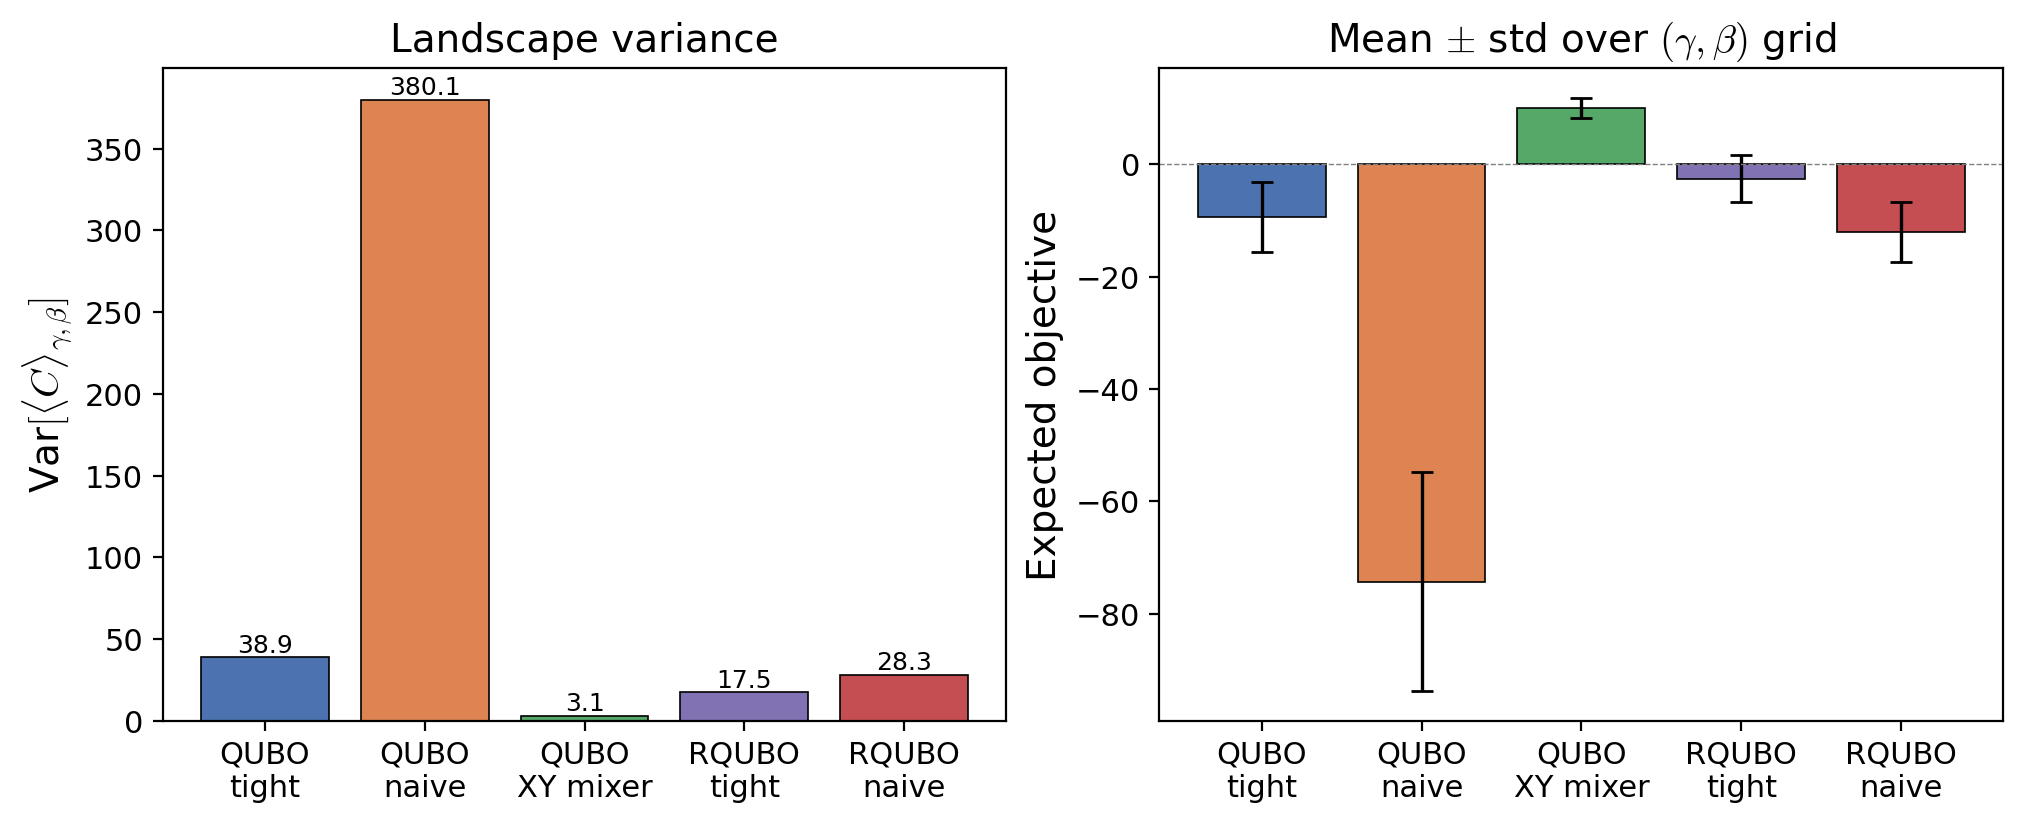

In [22]:
# ── Figure 3: Variance of expected objective across (γ, β) grid ──
all_labels = ["QUBO tight", "QUBO naive", "QUBO (XY)", "RQUBO tight", "RQUBO naive"]
display_names = ["QUBO\ntight", "QUBO\nnaive", "QUBO\nXY mixer", "RQUBO\ntight", "RQUBO\nnaive"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#8172B3", "#C44E52"]

means = [np.mean(landscapes[l]) for l in all_labels]
stds  = [np.std(landscapes[l])  for l in all_labels]
var   = [np.var(landscapes[l])  for l in all_labels]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# Left: variance bar chart
bars = axes[0].bar(display_names, var, color=colors, edgecolor="black", linewidth=0.6)
axes[0].set_ylabel("Var$[\\langle C \\rangle_{\\gamma,\\beta}]$")
axes[0].set_title("Landscape variance")
for bar, v in zip(bars, var):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f"{v:.1f}", ha="center", va="bottom", fontsize=9)

# Right: mean ± std
x = np.arange(len(all_labels))
axes[1].bar(x, means, yerr=stds, color=colors, edgecolor="black", linewidth=0.6,
            capsize=4, error_kw={"linewidth": 1.2})
axes[1].set_xticks(x)
axes[1].set_xticklabels(display_names)
axes[1].set_ylabel("Expected objective")
axes[1].set_title(r"Mean $\pm$ std over $(\gamma, \beta)$ grid")
axes[1].axhline(0, color="grey", linewidth=0.5, linestyle="--")

var_pdf = os.path.join(DATA_DIR, "landscape_variance.pdf")
fig.savefig(var_pdf, bbox_inches="tight")
print("Saved:", var_pdf)
plt.show()